In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# PyTorch & NLP Tools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

d:\Project\01 Skills\AI-Resume-Screener\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. Load Data
print("Loading Data...")
df = pd.read_csv("../data/processed/resumes_cleaned.csv").dropna()

X_text = df['cleaned_text'].tolist()
y_label = df['label']

# Encode Labels menjadi integer
encoder = LabelEncoder()
y = encoder.fit_transform(y_label)
num_classes = len(encoder.classes_)

print(f"Total data: {len(df)} resumes")
print(f"Total classes to predict: {num_classes}")

Loading Data...
Total data: 2483 resumes
Total classes to predict: 24


In [3]:
# 3. Extract Features menggunakan Sentence Transformers
# Catatan: Proses ini butuh waktu beberapa menit jika menggunakan CPU.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("Loading SentenceTransformer model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)

print("Generating semantic embeddings untuk seluruh data resume...")
start_time = time.time()
X_embeddings = embedder.encode(X_text, show_progress_bar=True)
print(f"Selesai dalam {time.time() - start_time:.2f} detik. Shape: {X_embeddings.shape}")

Using device: cpu
Loading SentenceTransformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2083.10it/s]


Generating semantic embeddings untuk seluruh data resume...


Batches: 100%|██████████| 78/78 [03:26<00:00,  2.65s/it]


Selesai dalam 207.07 detik. Shape: (2483, 384)


In [4]:
# 4. PyTorch Dataset & DataLoader
# Split data 80/20
X_train, X_test, y_train, y_test = train_test_split(X_embeddings, y, test_size=0.2, random_state=42, stratify=y)

# Buat Custom Dataset Class standar PyTorch
class ResumeDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.x = torch.FloatTensor(embeddings)
        self.y = torch.LongTensor(labels)
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# Buat DataLoader untuk batching
train_dataset = ResumeDataset(X_train, y_train)
test_dataset = ResumeDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print("DataLoaders siap!")

DataLoaders siap!


In [5]:
# 5. Membangun Arsitektur Neural Network
class ResumeClassifierNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(ResumeClassifierNN, self).__init__()
        # Input layer (384) -> Hidden 1 (256) -> ReLU -> Dropout -> Hidden 2 (128) -> ReLU -> Output (25)
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),   # Normalisasi batch mempercepat training
            nn.ReLU(),
            nn.Dropout(0.3),       # Mencegah overfitting
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.network(x)

# Inisialisasi model
input_dim = X_embeddings.shape[1]  # 384 dari MiniLM
model = ResumeClassifierNN(input_dim, num_classes).to(device)
print(model)

ResumeClassifierNN(
  (network): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=24, bias=True)
  )
)


In [6]:
# 6. Training Loop (Manual PyTorch Engine)
criterion = nn.CrossEntropyLoss() # Loss function untuk klasifikasi
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam Optimizer

epochs = 20
train_losses = []
test_accuracies = []

print("Mulai Training Neural Network...")
start_time = time.time()

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass & Optimize
        optimizer.zero_grad()  # Reset gradient
        loss.backward()        # Hitung gradient
        optimizer.step()       # Update bobot
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # --- EVALUATION PHASE ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad(): # Matikan hitungan gradient untuk testing (menghemat memori)
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    
    # Print status setiap 5 epoch
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

print(f"\nTraining Selesai dalam {time.time() - start_time:.2f} detik!")
print(f"🏆 Akurasi Akhir PyTorch Neural Network: {test_accuracies[-1]:.2f}%")

Mulai Training Neural Network...
Epoch [1/20] | Loss: 2.2393 | Test Accuracy: 61.97%
Epoch [5/20] | Loss: 0.8679 | Test Accuracy: 73.24%
Epoch [10/20] | Loss: 0.5786 | Test Accuracy: 75.45%
Epoch [15/20] | Loss: 0.3703 | Test Accuracy: 75.25%
Epoch [20/20] | Loss: 0.3238 | Test Accuracy: 74.65%

Training Selesai dalam 8.20 detik!
🏆 Akurasi Akhir PyTorch Neural Network: 74.65%


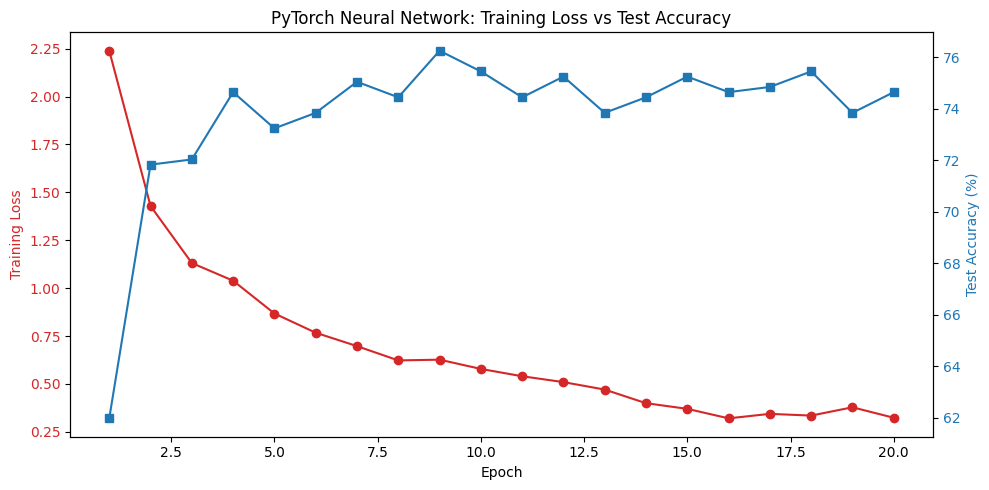

In [7]:
# 7. Visualisasi Training Process
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(range(1, epochs+1), train_losses, color=color, marker='o', label='Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Test Accuracy (%)', color=color)
ax2.plot(range(1, epochs+1), test_accuracies, color=color, marker='s', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('PyTorch Neural Network: Training Loss vs Test Accuracy')
fig.tight_layout()  
plt.show()